# Оценка вероятности того, что пациент выживет


## 3. Модели и оценка

## 1. Загрузка данных и библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, 
                             recall_score, f1_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Настройки графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Загрузка данных

X_train_woe = pd.read_parquet('X_train_woe.parquet')
X_test_woe = pd.read_parquet('X_test_woe.parquet')
X_train_target = pd.read_parquet('X_train_target.parquet')
X_test_target = pd.read_parquet('X_test_target.parquet')
y_train = pd.read_parquet('y_train.parquet').values.ravel()
y_test = pd.read_parquet('y_test.parquet').values.ravel()

# Расчет веса класса для дисбаланса (смертность ~8.6%)
scale_pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()

## 2. Определение моделей и параметров для поиска

In [3]:
# 2. Настройка моделей (СОКРАЩЕННЫЙ ВАРИАНТ: 3 модели)

# Модель 1: Logistic Regression на WoE
# Почему: LR линейна, WoE линеаризует признаки. Идеальная пара.
lr_params = {
    'C': np.logspace(-3, 3, 5), # Уменьшили сетку для скорости
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'max_iter': [1000]
}
model_lr = LogisticRegression(class_weight='balanced', random_state=42)

# Модель 2: Random Forest на Target Encoding
# Почему: Деревьям не нужна линейность. Target Enc дает богатые признаки.
rf_params = {
    'n_estimators': [100, 200], # Уменьшили количество деревьев для скорости
    'max_depth': [10, 15, None],
    'min_samples_split': [5, 10],
    'class_weight': ['balanced']
}
model_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Модель 3: CatBoost на Target Encoding
# Почему: SOTA для табличных данных. Target Enc хорошо сочетается с градиентным бустингом.
cb_params = {
    'iterations': [300, 500],   # Ограничили итерации
    'learning_rate': [0.05, 0.1],
    'depth': [6, 8],
    'scale_pos_weight': [scale_pos_weight_val] # Важный параметр для дисбаланса
}
model_cb = CatBoostClassifier(random_seed=42, verbose=0, task_type="CPU")

# Словарь конфигураций: Имя -> (Модель, Параметры, Данные X_train, Данные X_test)
experiments = {
    'LogReg_WoE':       (model_lr, lr_params, X_train_woe, X_test_woe),
    'RandForest_Target': (model_rf, rf_params, X_train_target, X_test_target),
    'CatBoost_Target':   (model_cb, cb_params, X_train_target, X_test_target)
}


## 3. Функция обучения и оценки (с Бутстрэпом)
Напишем функцию, которая обучает модель, делает предсказания и считает метрики с доверительными интервалами через бутстрэп.

In [4]:
# 3. Функция оценки с быстрым Бутстрэпом

def bootstrap_ci_fast(y_true, y_pred_proba, n_bootstraps=100, ci=0.95):
    """Быстрый расчет ДИ для AUC-ROC"""
    rng = np.random.RandomState(42)
    scores = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        idx = rng.randint(0, n, n)
        # Пропускаем, если в выборке нет одного из классов
        if len(np.unique(y_true[idx])) < 2: continue
        scores.append(roc_auc_score(y_true[idx], y_pred_proba[idx]))
    
    if not scores: return 0.5, 0.5, 0.5
    scores = np.array(sorted(scores))
    lower = scores[int((1. - ci) / 2 * len(scores))]
    upper = scores[int((1. + ci) / 2 * len(scores))]
    mean = np.mean(scores)
    return mean, lower, upper

results_list = []

print("\nЗапуск обучения (3 модели)...")

for name, (model, params, X_tr, X_te) in experiments.items():
    print(f"--- Обучение {name} ---")
    
    # Кросс-валидация для поиска гиперпараметров
    # n_iter=5 и cv=3 значительно ускоряют процесс
    search = RandomizedSearchCV(
        model, params, 
        n_iter=5, 
        scoring='roc_auc', 
        cv=3, 
        random_state=42, 
        n_jobs=-1, 
        verbose=0
    )
    
    search.fit(X_tr, y_train)
    best_model = search.best_estimator_
    
    # Предсказания
    y_pred_proba = best_model.predict_proba(X_te)[:, 1]
    y_pred = best_model.predict(X_te)
    
    # Метрики
    auc = roc_auc_score(y_test, y_pred_proba)
    auc_mean, auc_low, auc_high = bootstrap_ci_fast(y_test, y_pred_proba, n_bootstraps=100)
    
    gini = 2 * auc - 1
    gini_mean = 2 * auc_mean - 1
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results_list.append({
        'Model': name,
        'AUC-ROC': auc,
        'AUC-ROC 95% CI': f"[{auc_low:.3f}-{auc_high:.3f}]",
        'Gini': gini,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'Proba': y_pred_proba, # Сохраняем для графиков
        'Best_Model': best_model,
        'X_Test': X_te # Сохраняем для важности признаков
    })

df_results = pd.DataFrame(results_list)


Запуск обучения (3 модели)...
--- Обучение LogReg_WoE ---
--- Обучение RandForest_Target ---
--- Обучение CatBoost_Target ---


## 4. Сводная таблица

In [5]:
print("\nСравнительная таблица:")
display_cols = ['Model', 'AUC-ROC', 'AUC-ROC 95% CI', 'Gini', 'Precision', 'Recall', 'F1']
print(df_results[display_cols].to_markdown(index=False))


Сравнительная таблица:
| Model             |   AUC-ROC | AUC-ROC 95% CI   |     Gini |   Precision |   Recall |       F1 |
|:------------------|----------:|:-----------------|---------:|------------:|---------:|---------:|
| LogReg_WoE        |  0.873819 | [0.865-0.883]    | 0.747638 |    0.268341 | 0.769425 | 0.397909 |
| RandForest_Target |  0.87491  | [0.867-0.882]    | 0.749819 |    0.747826 | 0.162982 | 0.267635 |
| CatBoost_Target   |  0.892871 | [0.886-0.900]    | 0.785742 |    0.30661  | 0.770689 | 0.438691 |


## 5. График ROC-кривых

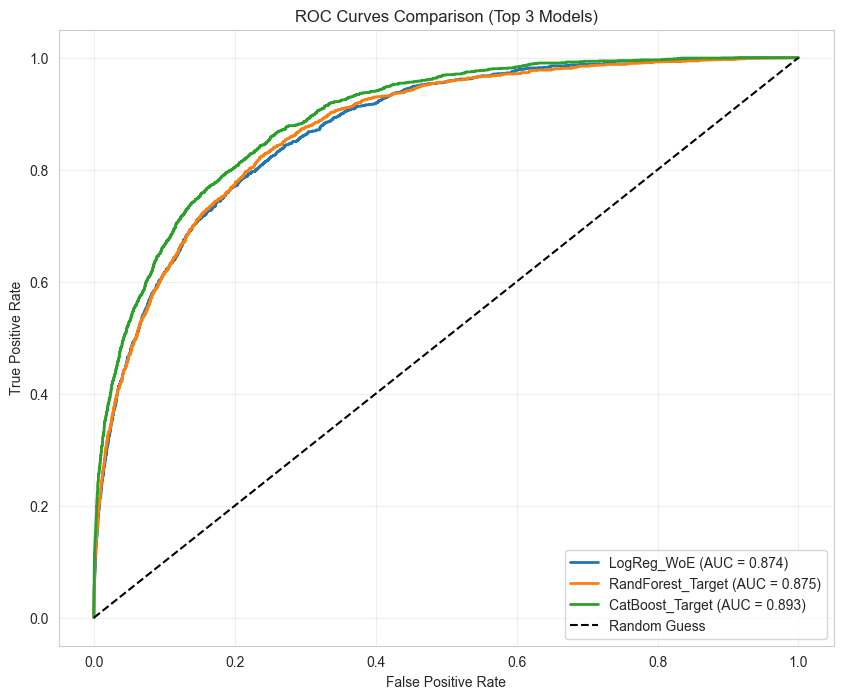

In [6]:
plt.figure(figsize=(10, 8))

for res in results_list:
    fpr, tpr, _ = roc_curve(y_test, res['Proba'])
    auc_val = res['AUC-ROC']
    plt.plot(fpr, tpr, label=f"{res['Model']} (AUC = {auc_val:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison (Top 3 Models)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Выбор лучшей модели и интерпретация


 Лучшая модель: CatBoost_Target
AUC-ROC: 0.8929


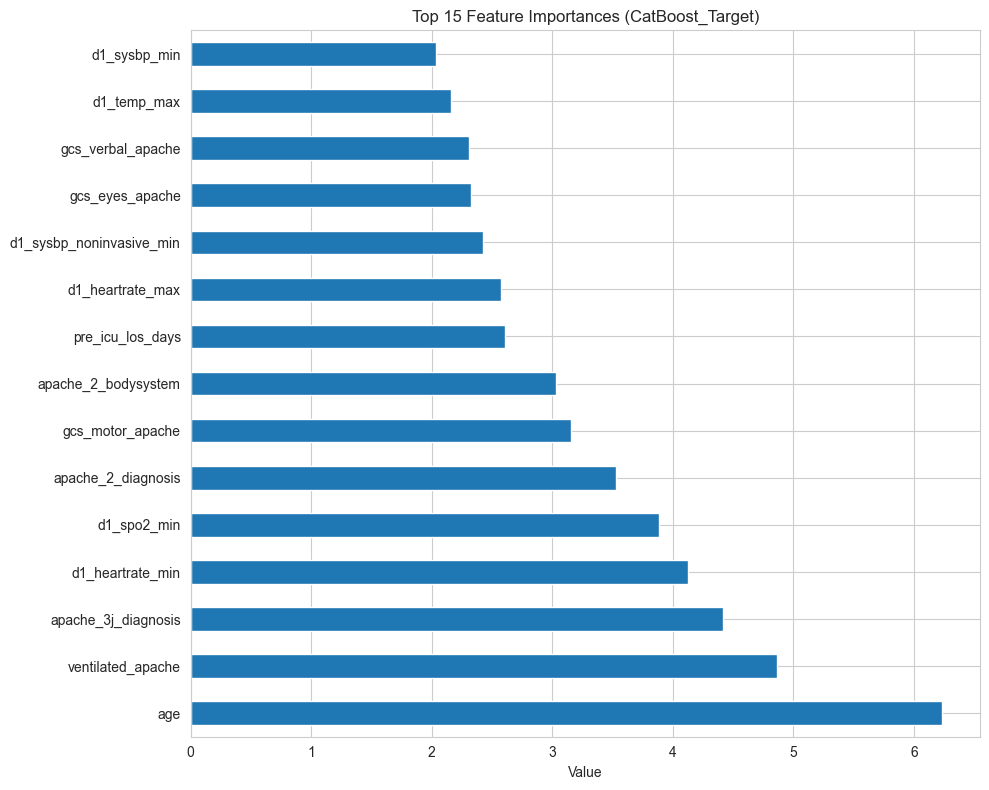


Топ-5 важных признаков:
age                    6.236378
ventilated_apache      4.861162
apache_3j_diagnosis    4.416990
d1_heartrate_min       4.127947
d1_spo2_min            3.882038
dtype: float64


In [7]:
best_idx = df_results['AUC-ROC'].idxmax()
best_res = df_results.loc[best_idx]
print(f"\n Лучшая модель: {best_res['Model']}")
print(f"AUC-ROC: {best_res['AUC-ROC']:.4f}")

model_obj = best_res['Best_Model']
X_test_used = best_res['X_Test']

# Получаем названия признаков
if 'WoE' in best_res['Model']:
    feature_names = X_train_woe.columns
else:
    feature_names = X_train_target.columns

plt.figure(figsize=(10, 8))

if best_res['Model'] == 'LogReg_WoE':
    # Для LR смотрим на коэффициенты
    coefs = pd.Series(model_obj.coef_[0], index=feature_names)
    top_n = 15
    # Сортируем по абсолютному влиянию
    top_coefs = coefs.abs().nlargest(top_n)
    # Берем оригинальные знаки
    plot_data = coefs.loc[top_coefs.index].sort_values()
    
    plot_data.plot(kind='barh')
    plt.title(f'Top {top_n} Coefficients (Logistic Regression)')
    plt.axvline(x=0, color='black', linewidth=0.8)

else:
    # Для деревьев (RF, CatBoost) смотрим Feature Importances
    importances = model_obj.feature_importances_
    feat_imp = pd.Series(importances, index=feature_names)
    top_n = 15
    feat_imp.nlargest(top_n).plot(kind='barh')
    plt.title(f'Top {top_n} Feature Importances ({best_res["Model"]})')

plt.xlabel('Value')
plt.tight_layout()
plt.show()

print("\nТоп-5 важных признаков:")
if best_res['Model'] == 'LogReg_WoE':
    print(coefs.abs().nlargest(5))
else:
    print(feat_imp.nlargest(5))

## 3. Инференс 1 записи через модель (pkl-файл)

## 1. Сохранение лучшей модели с данными

In [8]:
import joblib

# Получаем X_test, который использовался для этой модели
X_test_used = best_res['X_Test']

# Сохраняем словарь с моделью и примером данных (или названиями колонок)
bundle = {
    'model': model_obj,
    'feature_names': list(X_test_used.columns),
    'model_type': best_res['Model'] # Чтобы знать, какие данные подавать (WoE или Target)
}

joblib.dump(bundle, 'best_model_bundle.pkl')
print("Бандл (модель + метаданные) сохранен в best_model_bundle.pkl")

Бандл (модель + метаданные) сохранен в best_model_bundle.pkl


## 2. Инференс

In [9]:
print("Необходимые колонки для инференса:")
print(best_res['X_Test'].columns.tolist())

Необходимые колонки для инференса:
['age', 'bmi', 'elective_surgery', 'ethnicity', 'gender', 'height', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'weight', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'heart_rate_apache', 'intubated_apache', 'map_apache', 'resprate_apache', 'temp_apache', 'ventilated_apache', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_max', 'd1_mbp_min', 'd1_mbp_noninvasive_max', 'd1_mbp_noninvasive_min', 'd1_resprate_max', 'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_sysbp_max', 'd1_sysbp_min', 'd1_sysbp_noninvasive_max', 'd1_sysbp_noninvasive_min', 'd1_temp_max', 'd1_temp_min', 'h1_diasbp_max', 'h1_diasbp_min', 'h1_diasbp_noninvasive_max', 'h1_diasbp_noninvasive_min', 'h1_heartrate_max', 'h1_heartrate_min', 'h1_mbp_max',

In [13]:
import joblib
import pandas as pd
import numpy as np

# 1. Загружаем бандл (словарь)
bundle = joblib.load('best_model_bundle.pkl')

# 2. Извлекаем саму модель
model_obj = bundle['model']

# 3. Берем реальный пример из тестовых данных
# Убедитесь, что переменная best_res существует в памяти ноутбука!
new_patient_df = best_res['X_Test'].iloc[[0]].copy() 

# 4. Изменяем данные для симуляции "нового" пациента
new_patient_df['age'] = 90
new_patient_df['ventilated_apache'] = 1
new_patient_df['d1_heartrate_min'] = 110

# 5. Делаем предсказание
# predict_proba возвращает массив [[вероятность_0, вероятность_1]]
# [0] берет первую строку, [1] берет вероятность класса 1 (выжил)
probability = model_obj.predict_proba(new_patient_df)[0][1]
prediction = model_obj.predict(new_patient_df)[0]

print(f"Результат инференса")
print(f"Вероятность выживания: {probability:.2%}")
print(f"Прогноз класса (1 - выжил, 0 - нет): {prediction}")

# 6. Сравнение с исходным пациентом
# best_res['Proba'] - это numpy массив вероятностей для ВСЕГО теста
# Берем элемент с индексом 0 напрямую через []
original_prob = best_res['Proba'][0] 

print(f"\nДля сравнения, исходный пациент (индекс 0) имел вероятность: {original_prob:.2%}")
print(f"Изменение вероятности из-за новых параметров: {(probability - original_prob):.2%}")

Результат инференса
Вероятность выживания: 24.05%
Прогноз класса (1 - выжил, 0 - нет): 0

Для сравнения, исходный пациент (индекс 0) имел вероятность: 5.26%
Изменение вероятности из-за новых параметров: 18.79%
